In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

import warnings
warnings.filterwarnings('ignore')

# Dataset

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/eduardofc/data/refs/heads/main/airbnb_2019_2.csv")
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6.0,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2.0,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1.0,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1.0,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,NaN,0


In [3]:
df.shape

(48895, 12)

In [25]:
# elimino datos de price no-fiables

df = df[df.price > 10]
df.shape

(48867, 12)

# Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48703 non-null  str    
 1   neighbourhood                   48703 non-null  str    
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48830 non-null  str    
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   last_review                     38843 non-null  str    
 9   reviews_per_month               38843 non-null  float64
 10  calculated_host_listings_count  46502 non-null  float64
 11  availability_365                48895 non-null  int64  
dtypes: float64(4), int64(4), str(4)
memory usag

In [5]:
df.isna().sum()

neighbourhood_group                 192
neighbourhood                       192
latitude                              0
longitude                             0
room_type                            65
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count     2393
availability_365                      0
dtype: int64

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,48895.0,40.728949,0.054530,40.49979,40.69010,40.72307,40.763115,40.91306
longitude,48895.0,-73.952170,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
price,48895.0,152.720687,240.154170,0.00000,69.00000,106.00000,175.000000,10000.00000
minimum_nights,48895.0,7.029962,20.510550,1.00000,1.00000,3.00000,5.000000,1250.00000
number_of_reviews,48895.0,23.274466,44.550582,0.00000,1.00000,5.00000,24.000000,629.00000
reviews_per_month,38843.0,1.373221,1.680442,0.01000,0.19000,0.72000,2.020000,58.50000
calculated_host_listings_count,46502.0,7.177777,33.188298,1.00000,1.00000,1.00000,2.000000,327.00000
availability_365,48895.0,112.781327,131.622289,0.00000,0.00000,45.00000,227.000000,365.00000


In [18]:
df.describe(include='object').T

,count,unique,top,freq
neighbourhood_group,48703,5,Manhattan,21583
neighbourhood,48703,221,Williamsburg,3907
room_type,48830,3,Entire home/apt,25374
last_review,38843,1764,2019-06-23,1413


## Target

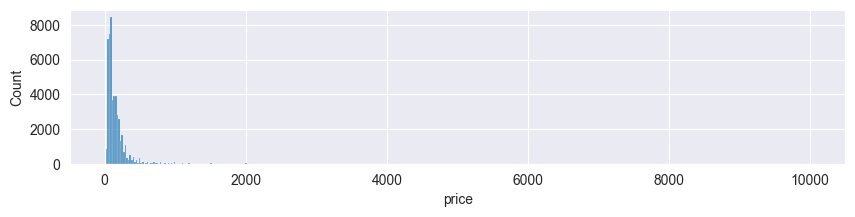

array([269., 355., 799.])

In [30]:
X = df['price']
# X_new = np.log(X)

plt.figure(figsize=(10,2))
# sns.histplot(X_new)
sns.histplot(X)
plt.show()

# 1) usar la target cruda
# 2) transformar la target
# 3) hacerla categorica
# 4) ensemble de modelos

np.quantile(X, [.9 ,.95 ,.99])

## fecha

In [44]:
df1 = df.copy()

df1['last_review'] = pd.to_datetime(df1['last_review'])

ref_date = pd.Timestamp('2019-12-31')
df1['last_review'] = (ref_date - df1['last_review']).dt.days

## Exploracion unidimensional

In [54]:
num_cols = [
    'latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
    'last_review', 'reviews_per_month', 'calculated_host_listings_count',
    'availability_365'
]
cat_cols = ['neighbourhood_group', 'neighbourhood', 'room_type',]

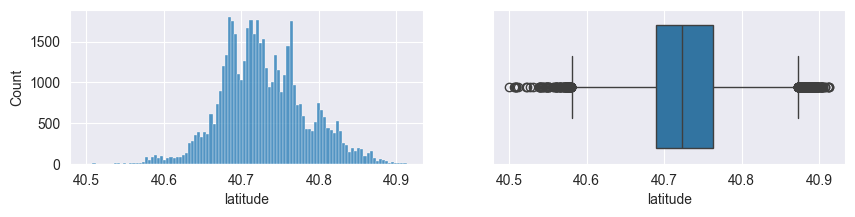

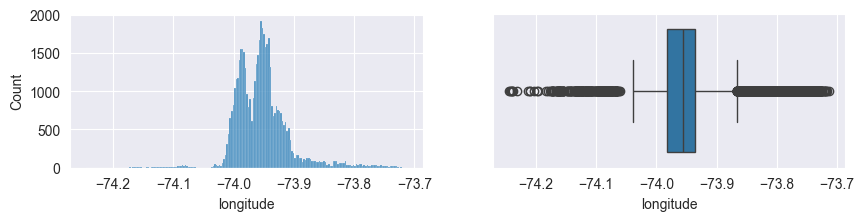

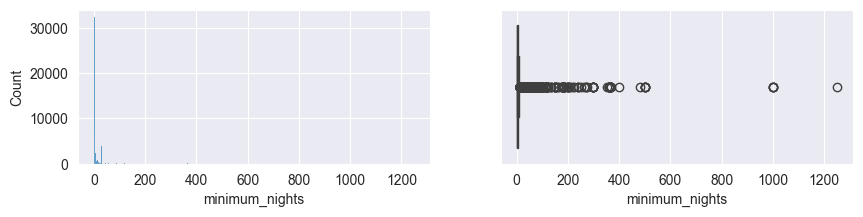

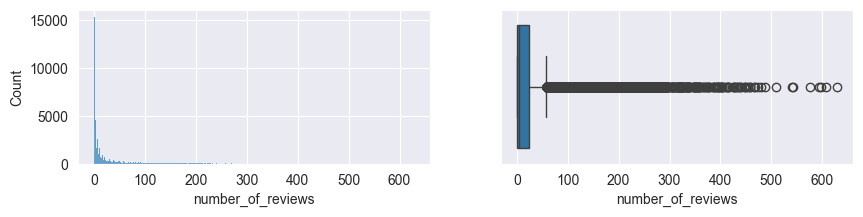

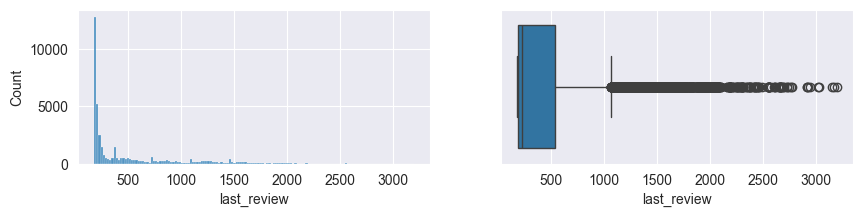

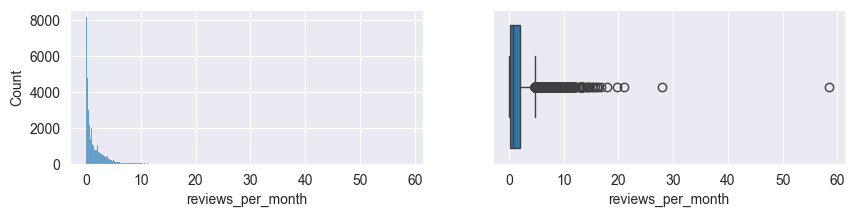

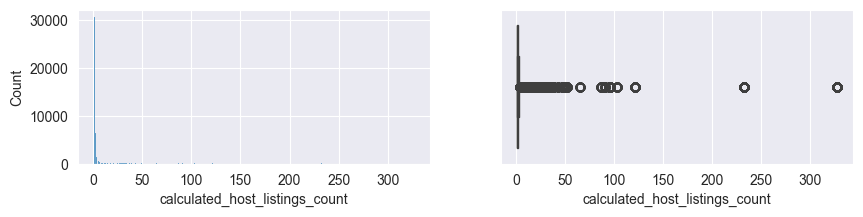

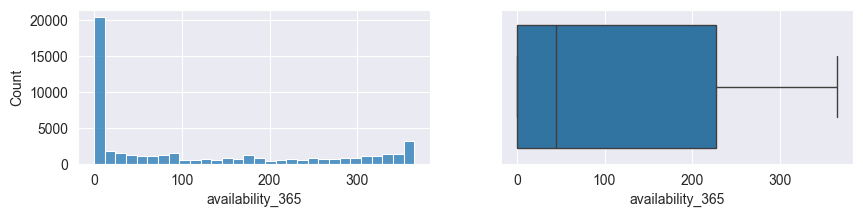

In [55]:
# numéricas

for col in num_cols:
    plt.figure(figsize=(10,2))
    plt.subplot(1,2,1)
    sns.histplot(data=df1, x=col)
    plt.subplot(1,2,2)
    sns.boxplot(data=df1, x=col)
    plt.show()

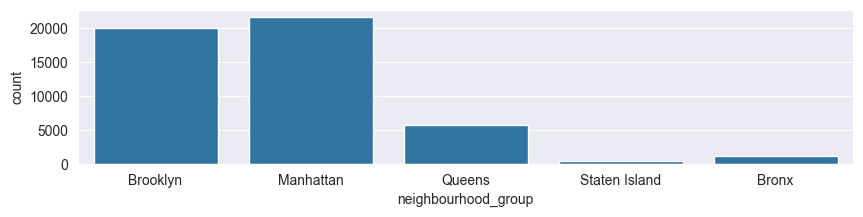

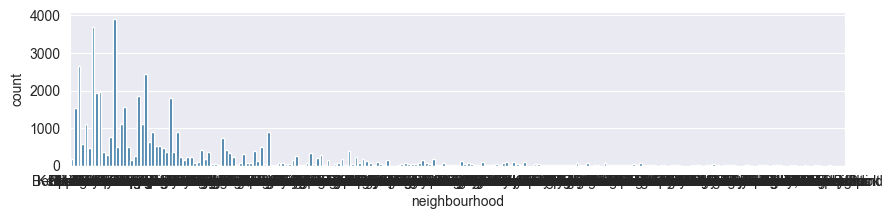

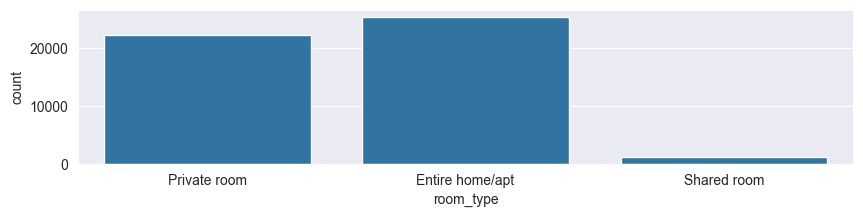

In [57]:
# categóricas

for col in cat_cols:
    plt.figure(figsize=(10,2))
    sns.countplot(data=df1, x=col)
    plt.show()

## Exploracion bidimensional

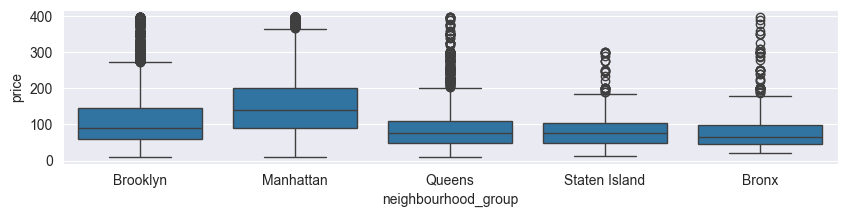

In [63]:
# numerica vs categorica

X = df1['price']
X = np.log(X)
X = df1[df1.price < 400]['price']

plt.figure(figsize=(10,2))
sns.boxplot(data=df1, y=X, x='neighbourhood_group')
plt.show()

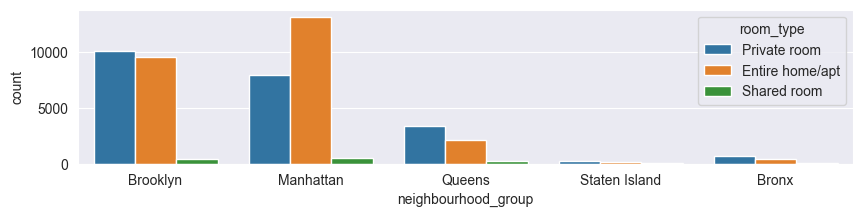

In [64]:
# dos categoricas

plt.figure(figsize=(10,2))
sns.countplot(data=df1, x="neighbourhood_group", hue='room_type')
plt.show()

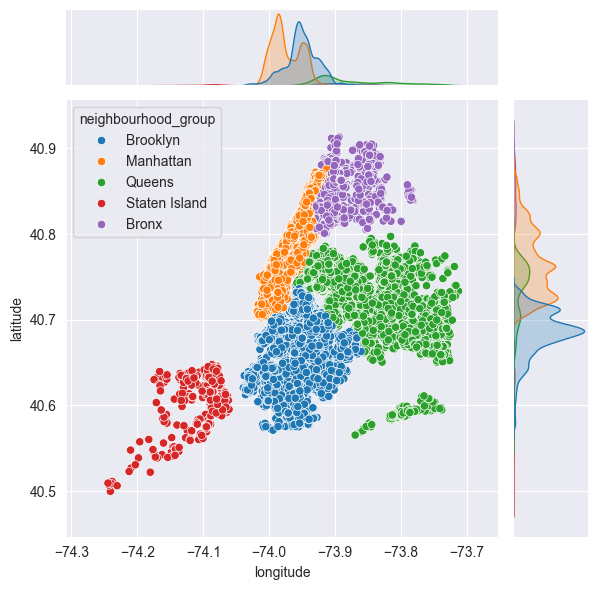

In [69]:
# dos numéricas

X1 = df1['longitude']
X2 = df1['latitude']
X3 = df1['neighbourhood_group']

sns.jointplot(x=X1, y=X2, hue=X3)

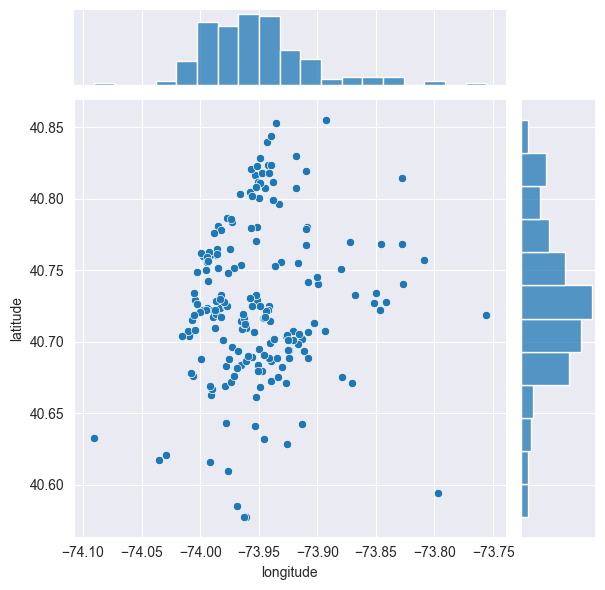

In [75]:
df_na_neigh = df1.copy()
df_na_neigh = df_na_neigh[df_na_neigh.neighbourhood_group.isna()]

X1 = df_na_neigh['longitude']
X2 = df_na_neigh['latitude']

sns.jointplot(x=X1, y=X2)

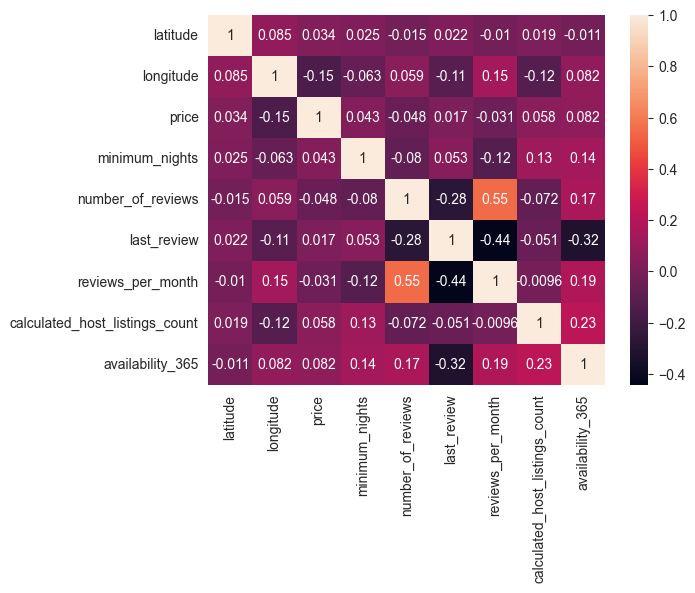

In [77]:
sns.heatmap(df1.corr(numeric_only=True), annot=True)
plt.show()

# Feature Engineering

In [82]:
X = df1['room_type']
print(X.shape)
X = df1[['room_type']]
print(X.shape)
X = df1[['room_type', 'availability_365']]
print(X.shape)

(48867,)
(48867, 1)
(48867, 2)


In [161]:
df2 = df1.copy()

## Nulos

In [162]:
df2.isna().sum()

neighbourhood_group                 192
neighbourhood                       192
latitude                              0
longitude                             0
room_type                            65
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10046
reviews_per_month                 10046
calculated_host_listings_count     2392
availability_365                      0
dtype: int64

In [163]:
from sklearn.impute import SimpleImputer, KNNImputer

In [164]:
# simple

X = df2[['room_type']]

imputer = SimpleImputer(strategy='most_frequent')
imputer.fit(X)
X_new = imputer.transform(X)

In [165]:
df2[['room_type']] = X_new

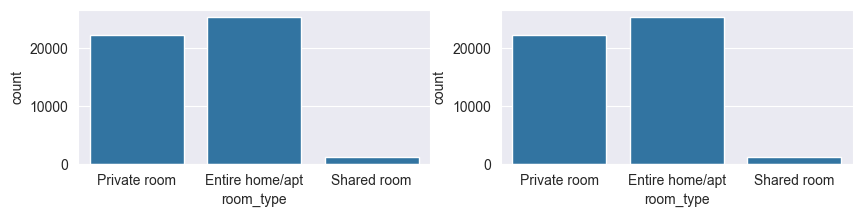

In [166]:
plt.figure(figsize=(10,2))
plt.subplot(1,2,1)
sns.countplot(data=df1, x='room_type')
plt.subplot(1,2,2)
sns.countplot(data=df2, x='room_type')
plt.show()

In [169]:
X = df2[['reviews_per_month']]

imputer = SimpleImputer(strategy='median')
X_new = imputer.fit_transform(X)

In [170]:
df2[['reviews_per_month']] = X_new

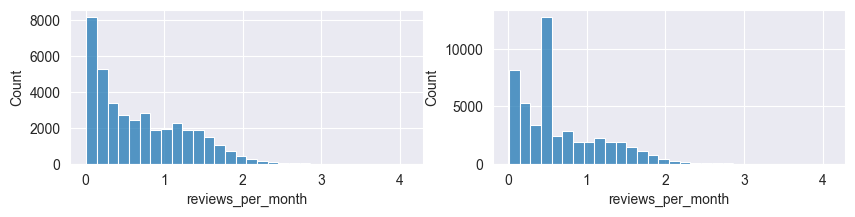

In [174]:
X1 = np.log(df1['reviews_per_month'] + 1)
X2 = np.log(df2['reviews_per_month'] + 1)

plt.figure(figsize=(10,2))
plt.subplot(1,2,1)
sns.histplot(X1, bins=30)
plt.subplot(1,2,2)
sns.histplot(X2, bins=30)
plt.show()

In [178]:
# knn

imputer = KNNImputer(n_neighbors=5)

cols = ['latitude', 'longitude', 'calculated_host_listings_count', 'last_review']
df2[cols] = imputer.fit_transform(df2[cols])

In [179]:
df1.isna().sum()

neighbourhood_group                 192
neighbourhood                       192
latitude                              0
longitude                             0
room_type                            65
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10046
reviews_per_month                 10046
calculated_host_listings_count     2392
availability_365                      0
dtype: int64

In [180]:
df2.isna().sum()

neighbourhood_group               192
neighbourhood                     192
latitude                            0
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                         0
reviews_per_month                   0
calculated_host_listings_count      0
availability_365                    0
dtype: int64

## Rescaling

In [182]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [183]:
df3 = df2.copy()

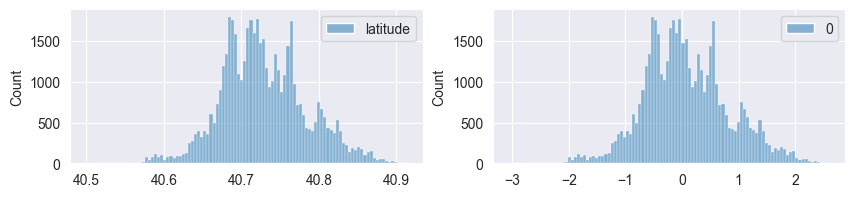

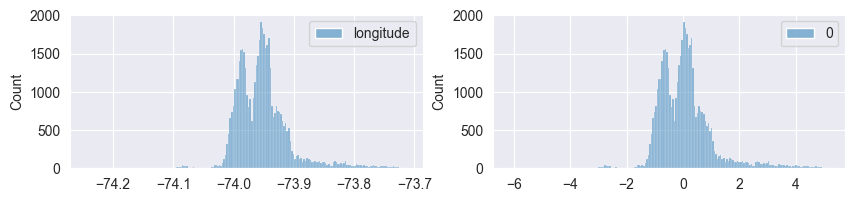

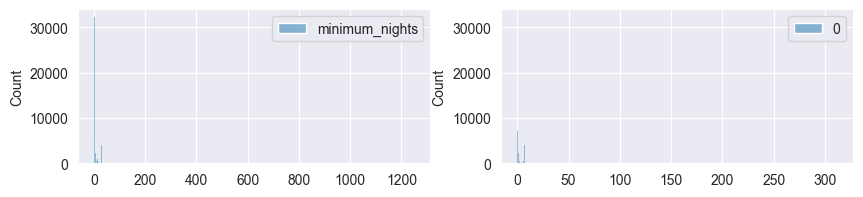

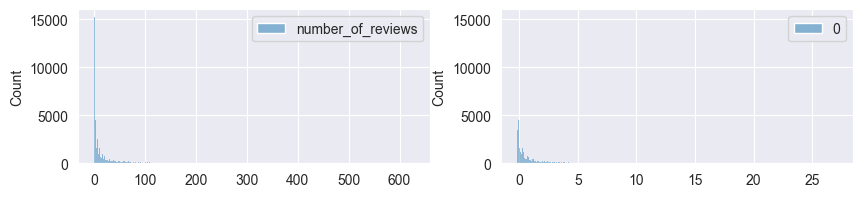

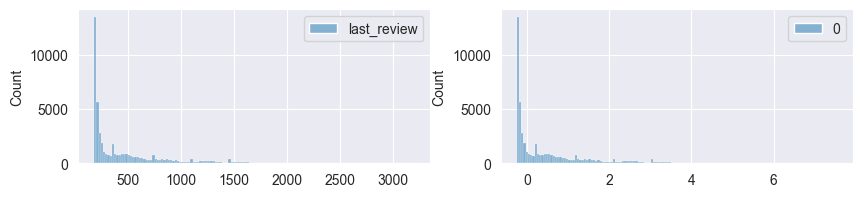

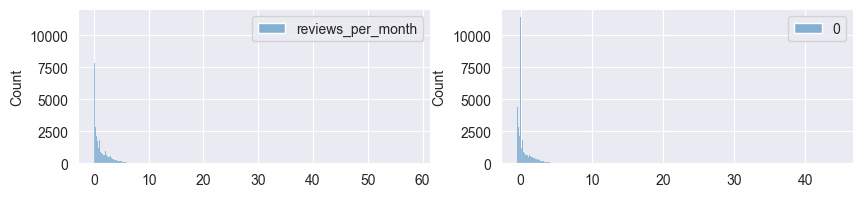

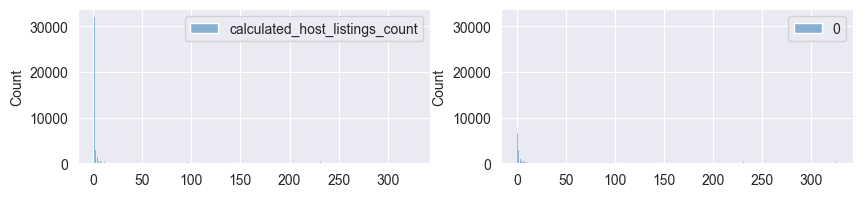

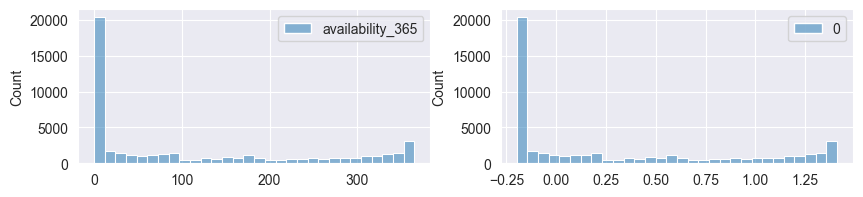

In [205]:
# scaler = MinMaxScaler()
# scaler = StandardScaler()
scaler = RobustScaler()

for col in num_cols:
    X = df3[[col]]
    X_new = scaler.fit_transform(X)

    plt.figure(figsize=(10,2))
    plt.subplot(1,2,1)
    sns.histplot(X)
    plt.subplot(1,2,2)
    sns.histplot(X_new)
    plt.show()

# Transformadores numéricos

In [206]:
from sklearn.preprocessing import KBinsDiscretizer, QuantileTransformer, PowerTransformer

### KBins

In [238]:
kbd = KBinsDiscretizer(strategy='uniform', n_bins=3)

X = df3[['minimum_nights']]
X_new = kbd.fit_transform(X)

In [239]:
kbd.get_feature_names_out()

array(['minimum_nights_0.0', 'minimum_nights_1.0', 'minimum_nights_2.0'],
      dtype=object)

In [240]:
df_kbd = pd.DataFrame(X_new.toarray())
df_kbd.columns = list(kbd.get_feature_names_out())
df_kbd.head()

,minimum_nights_0.0,minimum_nights_1.0,minimum_nights_2.0
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


### Quantile

In [244]:
qt = QuantileTransformer(n_quantiles=100, output_distribution='normal')
X_new = qt.fit_transform(X)

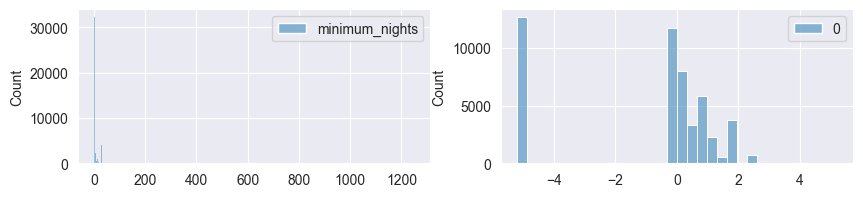

In [245]:
plt.figure(figsize=(10,2))
plt.subplot(1,2,1)
sns.histplot(X)
plt.subplot(1,2,2)
sns.histplot(X_new)
plt.show()

### Box-Cox

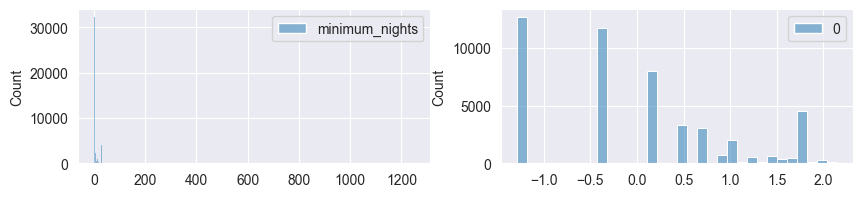

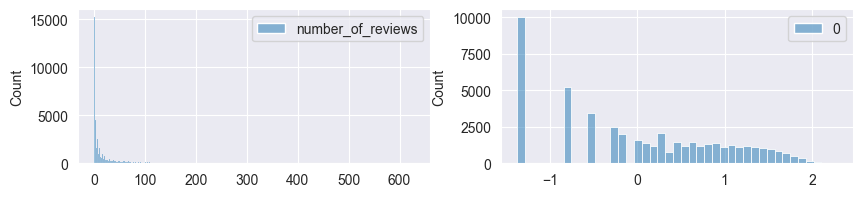

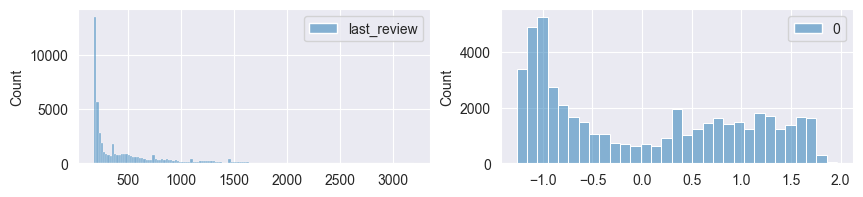

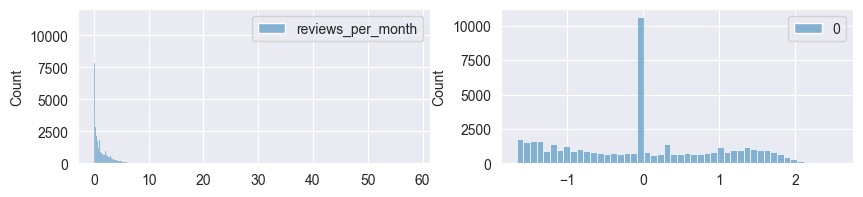

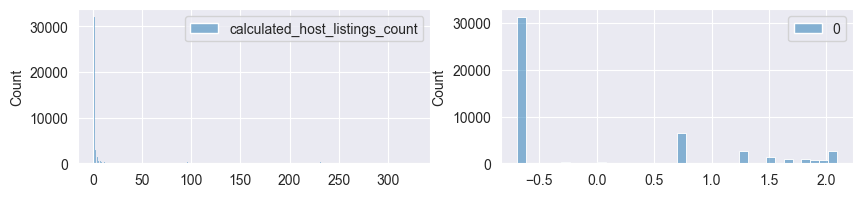

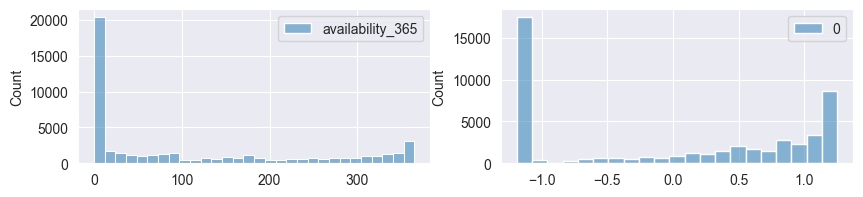

In [252]:
# pt = PowerTransformer(method='box-cox')
pt = PowerTransformer(method='yeo-johnson')

for col in num_cols:
    if not col in ['latitude', 'longitude']:
        X = df3[[col]] #+ 1
        X_new = pt.fit_transform(X)
    
        plt.figure(figsize=(10,2))
        plt.subplot(1,2,1)
        sns.histplot(X)
        plt.subplot(1,2,2)
        sns.histplot(X_new)
        plt.show()

In [260]:
# pd.cut(df3['availability_365'], bins=[-1,100,200,370], labels=[0,1,2])

## Transformadores categóricos

In [422]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [423]:
df4 = df3.copy()

In [424]:
le_ng = LabelEncoder()
le_n = LabelEncoder()

df4['neighbourhood_group_encoded'] = le_ng.fit_transform(df4['neighbourhood_group'])
df4['neighbourhood_encoded'] = le_n.fit_transform(df4['neighbourhood'])

In [425]:
le_n.classes_
le_ng.classes_

array(['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island', nan],
      dtype=object)

In [426]:
df4.isna().sum()

neighbourhood_group               192
neighbourhood                     192
latitude                            0
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                         0
reviews_per_month                   0
calculated_host_listings_count      0
availability_365                    0
neighbourhood_group_encoded         0
neighbourhood_encoded               0
dtype: int64

In [427]:
df4.loc[df_na_neigh.index, ['neighbourhood_group_encoded','neighbourhood_encoded']] = np.nan

In [429]:
df4.isna().sum()

neighbourhood_group               192
neighbourhood                     192
latitude                            0
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                         0
reviews_per_month                   0
calculated_host_listings_count      0
availability_365                    0
neighbourhood_group_encoded       192
neighbourhood_encoded             192
dtype: int64

In [430]:
df_na_neigh.iloc[147]
df4.iloc[147]

neighbourhood_group                           NaN
neighbourhood                                 NaN
latitude                                 40.72354
longitude                               -73.98295
room_type                         Entire home/apt
price                                         195
minimum_nights                                  3
number_of_reviews                              30
last_review                                 197.0
reviews_per_month                            0.28
calculated_host_listings_count                1.4
availability_365                              248
neighbourhood_group_encoded                   NaN
neighbourhood_encoded                         NaN
Name: 147, dtype: object

In [431]:
# knn

key_cols = ['latitude', 'longitude', 'neighbourhood_group_encoded', 'neighbourhood_encoded']

imputer = KNNImputer(n_neighbors=5, weights='distance')
df4[key_cols] = imputer.fit_transform(df4[key_cols])

In [434]:
# quitamos float -> int

df4['neighbourhood_group_encoded'] = np.round(df4['neighbourhood_group_encoded']).astype(int)
df4['neighbourhood_encoded'] = np.round(df4['neighbourhood_encoded']).astype(int)

In [435]:
df4.iloc[145:150]

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_encoded,neighbourhood_encoded
145,Brooklyn,Williamsburg,40.71596,-73.93938,Entire home/apt,160,3,11,182.0,0.11,1.0,188,1,214
146,Brooklyn,Williamsburg,40.71492,-73.95935,Entire home/apt,195,4,240,197.0,2.19,1.0,214,1,214
147,NaN,NaN,40.72354,-73.98295,Entire home/apt,195,3,30,197.0,0.28,1.4,248,2,64
148,Brooklyn,Williamsburg,40.71165,-73.96087,Private room,80,3,200,192.0,1.86,4.0,262,1,214
149,Brooklyn,Fort Greene,40.69101,-73.97312,Private room,44,8,27,185.0,1.05,5.0,280,1,80


In [436]:
df4.isna().sum()

neighbourhood_group               192
neighbourhood                     192
latitude                            0
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                         0
reviews_per_month                   0
calculated_host_listings_count      0
availability_365                    0
neighbourhood_group_encoded         0
neighbourhood_encoded               0
dtype: int64

In [437]:
# inverse transform

df4['neighbourhood_group'] = le_ng.inverse_transform(df4['neighbourhood_group_encoded'])
df4['neighbourhood'] = le_n.inverse_transform(df4['neighbourhood_encoded'])

In [438]:
df4.iloc[145:150]

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_encoded,neighbourhood_encoded
145,Brooklyn,Williamsburg,40.71596,-73.93938,Entire home/apt,160,3,11,182.0,0.11,1.0,188,1,214
146,Brooklyn,Williamsburg,40.71492,-73.95935,Entire home/apt,195,4,240,197.0,2.19,1.0,214,1,214
147,Manhattan,East Village,40.72354,-73.98295,Entire home/apt,195,3,30,197.0,0.28,1.4,248,2,64
148,Brooklyn,Williamsburg,40.71165,-73.96087,Private room,80,3,200,192.0,1.86,4.0,262,1,214
149,Brooklyn,Fort Greene,40.69101,-73.97312,Private room,44,8,27,185.0,1.05,5.0,280,1,80


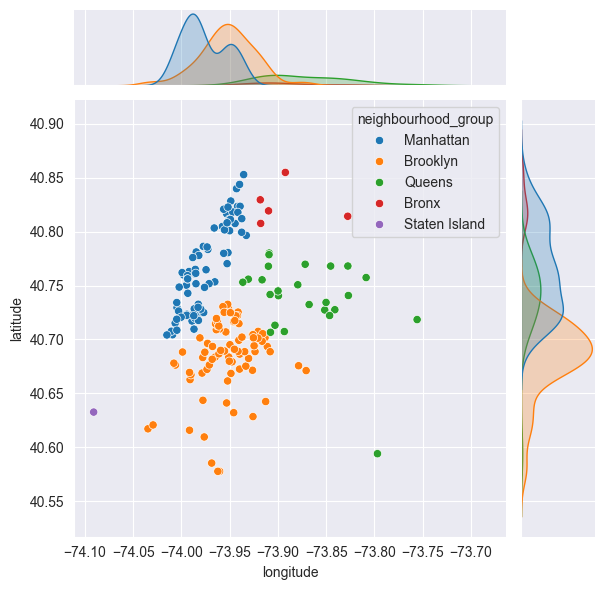

In [439]:
X1 = df4.iloc[df3.neighbourhood_group.isna()]['longitude']
X2 = df4.iloc[df3.neighbourhood_group.isna()]['latitude']
X3 = df4.iloc[df3.neighbourhood_group.isna()]['neighbourhood_group']

sns.jointplot(x=X1, y=X2, hue=X3)

In [440]:
df4.drop(columns=['neighbourhood_encoded', 'neighbourhood_group_encoded'], inplace=True)

# OneHotEncoder

In [441]:
df5 =df4.copy()

In [458]:
# neighbourhood_group
X = df4[['neighbourhood_group']]
ohe_ng = OneHotEncoder()
X_new_ng = ohe_ng.fit_transform(X)

# room_type
X = df4[['room_type']]
ohe_rt = OneHotEncoder(drop='first')
X_new_rt = ohe_rt.fit_transform(X)

# neighbourhood
X = df4[['neighbourhood']]
ohe_n = OneHotEncoder(max_categories=5)
X_new_n = ohe_n.fit_transform(X)

In [462]:
ohe_n.categories_
X_new_n.toarray()
ohe_n.get_feature_names_out()

array(['neighbourhood_Bedford-Stuyvesant', 'neighbourhood_Bushwick',
       'neighbourhood_Harlem', 'neighbourhood_Williamsburg',
       'neighbourhood_infrequent_sklearn'], dtype=object)

In [465]:
cat = [['Bedford-Stuyvesant', 'Bushwick',
       'Harlem', 'Williamsburg',
       'infrequent_sklearn']]

X = df4[['neighbourhood']]
ohe_n = OneHotEncoder(categories=cat, handle_unknown='ignore')
X_new_n = ohe_n.fit_transform(X)

In [467]:
X_new_n.toarray()

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       ...,
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]], shape=(48867, 5))

In [472]:
# df5.drop(columns=cat_cols, inplace=True)

df_n = pd.DataFrame(X_new_n.toarray(), columns=ohe_n.get_feature_names_out(), index=df4.index)
df_ng = pd.DataFrame(X_new_ng.toarray(), columns=ohe_ng.get_feature_names_out(), index=df4.index)
df_rt = pd.DataFrame(X_new_rt.toarray(), columns=ohe_rt.get_feature_names_out(), index=df4.index)

df5 = df5.merge(df_n, left_index=True, right_index=True)
df5 = df5.merge(df_ng, left_index=True, right_index=True)
df5 = df5.merge(df_rt, left_index=True, right_index=True)

In [473]:
df5.info()

<class 'pandas.DataFrame'>
Index: 48867 entries, 0 to 48894
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   latitude                           48867 non-null  float64
 1   longitude                          48867 non-null  float64
 2   price                              48867 non-null  int64  
 3   minimum_nights                     48867 non-null  int64  
 4   number_of_reviews                  48867 non-null  int64  
 5   last_review                        48867 non-null  float64
 6   reviews_per_month                  48867 non-null  float64
 7   calculated_host_listings_count     48867 non-null  float64
 8   availability_365                   48867 non-null  int64  
 9   neighbourhood_Bedford-Stuyvesant   48867 non-null  float64
 10  neighbourhood_Bushwick             48867 non-null  float64
 11  neighbourhood_Harlem               48867 non-null  float64
 12  neighb

In [475]:
pd.set_option('display.max_columns', None)
df5.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_Bedford-Stuyvesant,neighbourhood_Bushwick,neighbourhood_Harlem,neighbourhood_Williamsburg,neighbourhood_infrequent_sklearn,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,149,1,9,438.0,0.21,6.0,365,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,40.75362,-73.98377,225,1,45,224.0,0.38,2.0,355,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,40.80902,-73.94190,150,3,0,621.2,0.72,1.0,365,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,40.68514,-73.95976,89,1,270,179.0,4.64,1.0,194,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,40.79851,-73.94399,80,10,9,407.0,0.10,1.8,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


# Model

In [478]:
from sklearn.linear_model import LinearRegression

X = df5.drop(columns='price')
y = df5['price']
y = np.l

model = LinearRegression()
model.fit(X, y)
y_hat = model.predict(X)

In [479]:
from sklearn.metrics import r2_score

r2_score(y_true=y, y_pred=y_hat)

0.10051156529141825